### 3D Phenotype Plots

/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_58775/1913455104.py:139: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(png_path,  dpi=300, bbox_inches='tight', pad_inches=0.3)


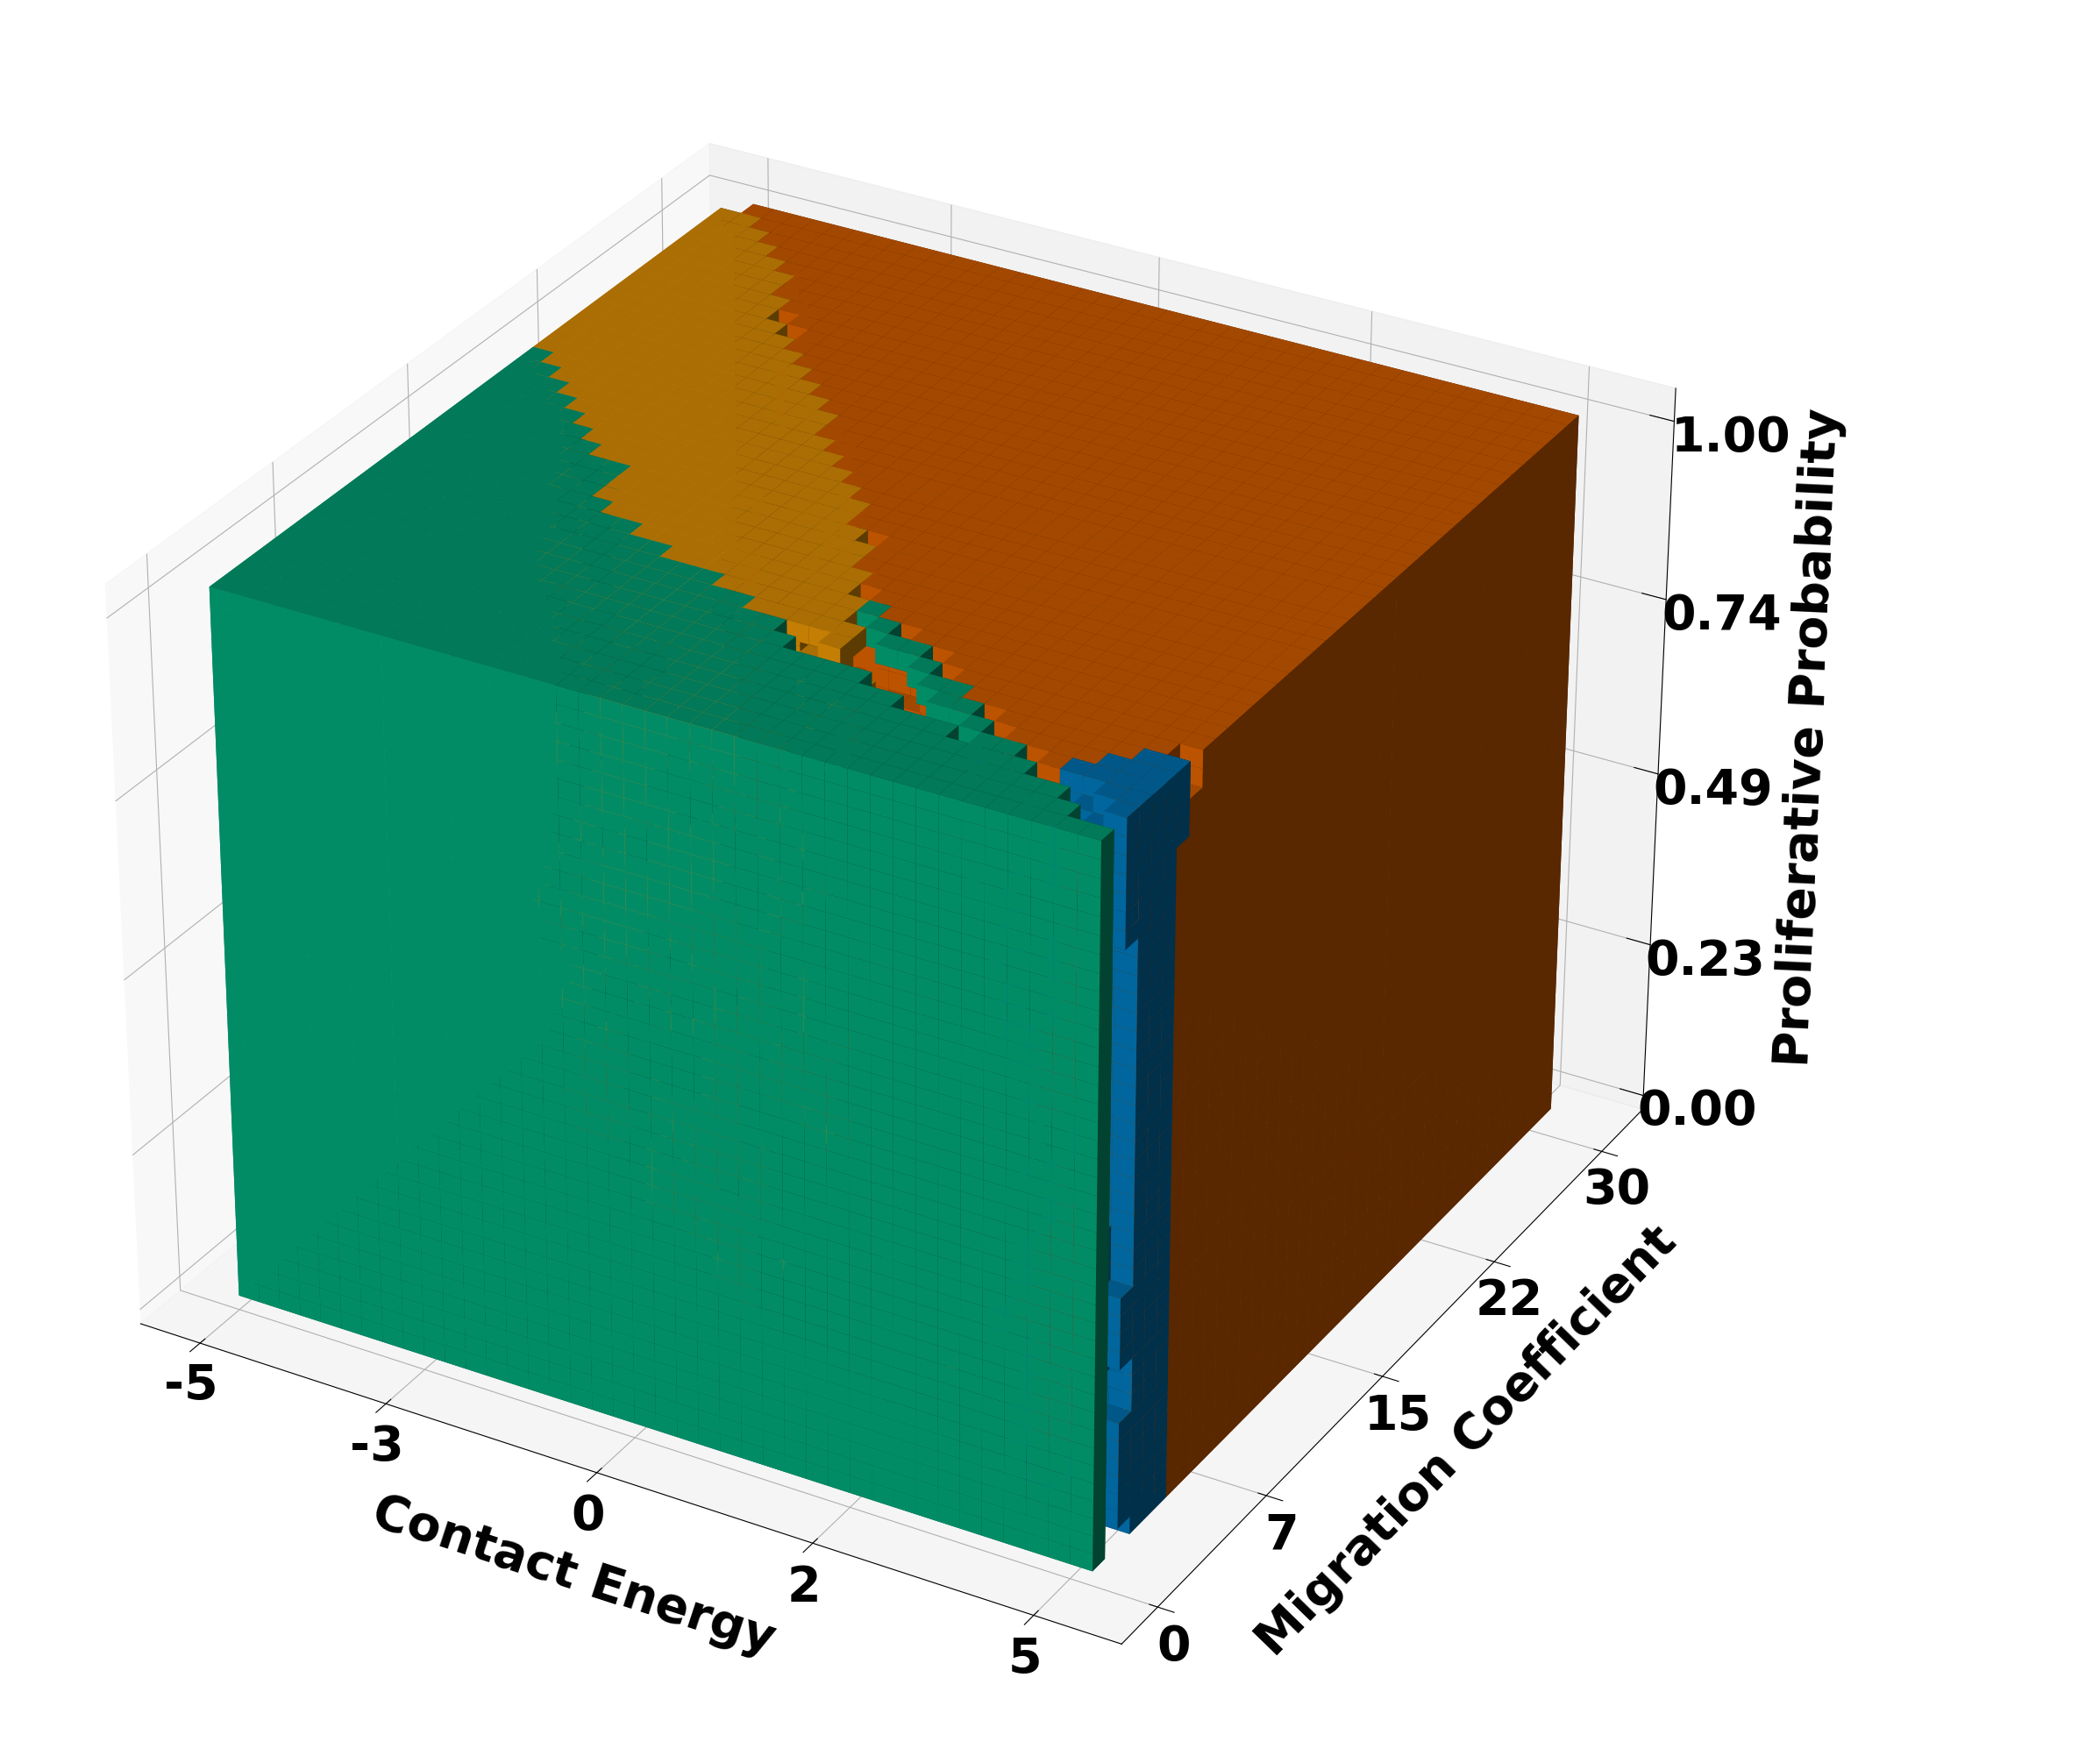

Saved PNG:  /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/Phenotypes/phenotype_phase_space.png
Saved TIFF: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/Phenotypes/phenotype_phase_space.tiff
Saved PDF:  /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/Phenotypes/phenotype_phase_space.pdf


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.patches import Patch
from matplotlib.font_manager import FontProperties
import seaborn as sns
from pathlib import Path

# =======================
# Inputs
# =======================
file_path = Path("../../Results/Data/phenotype_probability_map.csv")
if not file_path.exists():
    raise FileNotFoundError(f"File not found at: {file_path.resolve()}")

df = pd.read_csv(file_path)

# =======================
# Phenotype colors
# =======================
cb_palette = sns.color_palette("colorblind")
phenotype_colors = {
    "No invasion": cb_palette[2],           # teal-ish
    "Single cell invasion": cb_palette[0],  # blue
    "Bulk invasion": cb_palette[1],         # orange
    "Multimodal invasion": cb_palette[3]    # red-ish
}

# =======================
# Grid setup
# =======================
N = 40  # adjust as needed
x_vals = np.linspace(df["Contact Energy"].min(), df["Contact Energy"].max(), N)
y_vals = np.linspace(df["Chemotaxis Lambda"].min(), df["Chemotaxis Lambda"].max(), N)
z_vals = np.linspace(df["Proliferative Probability"].min(), df["Proliferative Probability"].max(), N)
X, Y, Z = np.meshgrid(x_vals, y_vals, z_vals, indexing='ij')

# Voxel occupancy + color arrays
voxel_grid = np.zeros((N, N, N), dtype=bool)
colors = np.empty(voxel_grid.shape + (3,), dtype=float)

# =======================
# Populate voxels where P(phenotype) > 0.5
# =======================
for phenotype, color in phenotype_colors.items():
    subset = df[df["Phenotype"] == phenotype]
    if len(subset) < 10:
        continue

    points = subset[["Contact Energy", "Chemotaxis Lambda", "Proliferative Probability"]].values
    probs = subset["Probability"].values

    grid = griddata(points, probs, (X, Y, Z), method="linear", fill_value=0.0)
    mask = grid > 0.5

    # Mark occupancy and set color (RGB tuple from seaborn)
    voxel_grid[mask] = True
    colors[mask] = np.array(color)

# =======================
# Figure 
# =======================
fig = plt.figure(figsize=(24, 20), constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[1, 0.14], wspace=0.05)  # right gutter
ax = fig.add_subplot(gs[0, 0], projection='3d')

# keep the right panel empty to act as margin
spacer_ax = fig.add_subplot(gs[0, 1])
spacer_ax.axis('off')



ax.voxels(voxel_grid, facecolors=colors, edgecolor=None)

# =======================
# Axes labels & ticks
# =======================
ax.set_xlabel("Contact Energy", fontsize=40, weight='bold', labelpad=35)
ax.set_ylabel("Migration Coefficient", fontsize=40, weight='bold', labelpad=35)
ax.set_zlabel("Proliferative Probability", fontsize=40, weight='bold', labelpad=55)


ax.zaxis.label.set_rotation(90)
# If you really want a nudge outward, keep it modest:
# ax.zaxis.set_label_coords(1.02, 0.5)

tick_indices = np.linspace(0, N - 1, 5, dtype=int)

ax.set_xticks(tick_indices)
ax.set_xticklabels([str(int(round(x_vals[i]))) for i in tick_indices])

ax.set_yticks(tick_indices)
ax.set_yticklabels([str(int(round(y_vals[i]))) for i in tick_indices])

ax.set_zticks(tick_indices)
ax.set_zticklabels([f"{z_vals[i]:.2f}" for i in tick_indices])

ax.tick_params(axis='both', which='major', labelsize=40, width=2)
ax.tick_params(axis='z', labelsize=40, width=1)
ax.tick_params(axis='z', which='major', pad=20)
ax.zaxis._axinfo['tick']['inward_factor']  = 0.0 
ax.zaxis._axinfo['tick']['outward_factor'] = 0.3

for tick in ax.get_xticklabels() + ax.get_yticklabels() + ax.get_zticklabels():
    tick.set_fontweight('bold')

# =======================
# Optional legend (off by default)
# =======================
SHOW_LEGEND = False
if SHOW_LEGEND:
    bold_font = FontProperties(weight='bold', size=24)
    legend_handles = [
        Patch(facecolor=phenotype_colors[k], edgecolor='black', label=k, alpha=1.0)
        for k in phenotype_colors
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper right",
        ncol=1,
        fontsize=24,
        prop=bold_font,
        frameon=True
    )

# =======================
# Save outputs (absolute paths) and ensure nothing is clipped
# =======================
out_dir = Path("../../Results/Plots/Phenotypes")
out_dir.mkdir(parents=True, exist_ok=True)
out_base = out_dir / "phenotype_phase_space"

png_path  = (out_base.with_suffix(".png")).resolve()
tiff_path = (out_base.with_suffix(".tiff")).resolve()
pdf_path  = (out_base.with_suffix(".pdf")).resolve()

# Avoid tight_layout; rely on constrained_layout + save padding
plt.savefig(png_path,  dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.savefig(tiff_path, dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.savefig(pdf_path,               bbox_inches='tight', pad_inches=0.3)

plt.show()

print("Saved PNG: ", png_path)
print("Saved TIFF:", tiff_path)
print("Saved PDF: ", pdf_path)


### Phase Space gif

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from matplotlib.patches import Patch
from matplotlib.font_manager import FontProperties
import os
from PIL import Image
import shutil
import seaborn as sns

# === Load Data ===
file_path = "../../Results/Data/phenotype_probability_map.csv"
df = pd.read_csv(file_path)


cb_palette = sns.color_palette("colorblind")
phenotype_colors = {
    "No invasion": cb_palette[2],           # sky blue
    "Single cell invasion": cb_palette[0],  # blue
    "Bulk invasion": cb_palette[1],         # orange
    "Multimodal invasion": cb_palette[3]    # gold
}
# === Grid Setup ===
N = 40
x_vals = np.linspace(df["Contact Energy"].min(), df["Contact Energy"].max(), N)
y_vals = np.linspace(df["Chemotaxis Lambda"].min(), df["Chemotaxis Lambda"].max(), N)
z_vals = np.linspace(df["Proliferative Probability"].min(), df["Proliferative Probability"].max(), N)
X, Y, Z = np.meshgrid(x_vals, y_vals, z_vals, indexing='ij')

voxel_grid = np.zeros((N, N, N), dtype=bool)
# colors = np.empty(voxel_grid.shape, dtype=object)
colors = np.empty(voxel_grid.shape + (3,), dtype=float) 


# === Fill the Voxel Grid ===
for phenotype, color in phenotype_colors.items():
    subset = df[df["Phenotype"] == phenotype]
    if len(subset) < 10:
        continue
    points = subset[["Contact Energy", "Chemotaxis Lambda", "Proliferative Probability"]].values
    probs = subset["Probability"].values
    grid = griddata(points, probs, (X, Y, Z), method='linear', fill_value=0)
    mask = grid > 0.5
    voxel_grid[mask] = True
    # colors[mask] = color
    colors[mask] = np.array(color)

# === Create Directory for Frames ===
frame_dir = "../../Results/Plots/Phenotypes/tmp_voxel_frames"
os.makedirs(frame_dir, exist_ok=True)

# === Prepare Tick Labels ===
tick_indices = np.linspace(0, N - 1, 5, dtype=int)
x_tick_labels = [f"{x_vals[i]:.1f}" for i in tick_indices]
y_tick_labels = [f"{y_vals[i]:.1f}" for i in tick_indices]
z_tick_labels = [f"{z_vals[i]:.2f}" for i in tick_indices]

# === Legend Handles ===
legend_handles = [Patch(facecolor=color, edgecolor='black', label=phen) for phen, color in phenotype_colors.items()]

# === Generate Frames ===
angles = np.linspace(0, 360, 36, endpoint=False)
images = []

for i, angle in enumerate(angles):
    fig = plt.figure(figsize=(18, 16))
    ax = fig.add_subplot(111, projection='3d')
    ax.voxels(voxel_grid, facecolors=colors, edgecolor=None)

    # Set view angle
    ax.view_init(elev=30, azim=angle)

    # Set axis labels
    ax.set_xlabel("Contact Energy", fontsize=16, weight='bold')
    ax.set_ylabel("Migration Coefficient", fontsize=16, weight='bold')
    ax.set_zlabel("Proliferative Probability", fontsize=16, weight='bold')

    # Set tick positions and labels
    ax.set_xticks(tick_indices)
    ax.set_xticklabels(x_tick_labels, fontsize=12, weight='bold')
    ax.set_yticks(tick_indices)
    ax.set_yticklabels(y_tick_labels, fontsize=12, weight='bold')
    ax.set_zticks(tick_indices)
    ax.set_zticklabels(z_tick_labels, fontsize=12, weight='bold')

    # Aspect ratio
    ax.set_box_aspect([1, 1, 1])

    # Add legend to each frame
    ax.legend(handles=legend_handles, loc='upper left', fontsize=14)

    # Save frame
    output_frame = os.path.join(frame_dir, f"frame_{i:02d}.png")
    plt.tight_layout()
    plt.savefig(output_frame, dpi=100)
    plt.close()
    images.append(Image.open(output_frame))

# === Save GIF ===
gif_path = "../../Results/Plots/Phenotypes/Phenotype_3D_Phase_Space.gif"
images[0].save(gif_path, save_all=True, append_images=images[1:], duration=150, loop=0)

# === Cleanup Temporary Frames ===
shutil.rmtree(frame_dir)

print(f"Voxel rotation GIF with legend saved to: {gif_path}")


### Phenotype Distribution

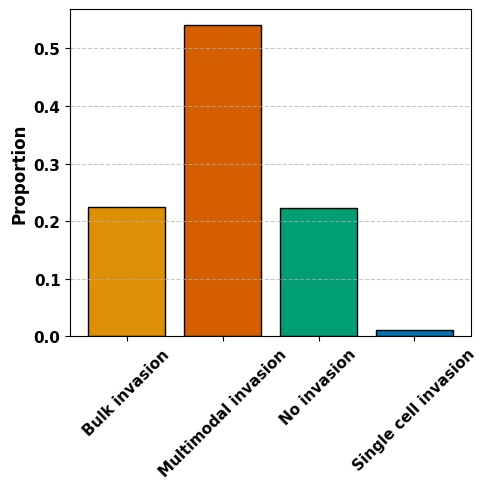

Bar chart saved to: ../../Results/Plots/Phenotypes/phenotype_distribution.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load classified phenotype data
file_path = "../../Results/Data/phenotype_classification.csv"
df = pd.read_csv(file_path)

# Count and normalize
phenotype_counts = df["Phenotype"].value_counts(normalize=True).sort_index()


cb_palette = sns.color_palette("colorblind")
bar_colors = {
    "No invasion": cb_palette[2],           # sky blue
    "Single cell invasion": cb_palette[0],  # blue
    "Bulk invasion": cb_palette[1],         # orange
    "Multimodal invasion": cb_palette[3]    # gold
}
# Get colors in the right order
color_list = [bar_colors[phen] for phen in phenotype_counts.index]

# Plot
plt.figure(figsize=(5, 5))
bars = plt.bar(phenotype_counts.index, phenotype_counts.values, color=color_list, edgecolor="black")

# Add labels
plt.ylabel("Proportion", fontsize=12, weight='bold')
plt.xticks(rotation=45, fontsize=11, weight='bold')
plt.yticks(fontsize=11, weight='bold')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

# Save and show
save_path = "../../Results/Plots/Phenotypes/phenotype_distribution.png"
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Bar chart saved to: {save_path}")


#### With Error bars

Number of replicate indices found: 10
Replicate
0    1331
1    1331
2    1331
3    1331
4    1331
Name: count, dtype: int64
Mean phenotype proportions across replicates:
Phenotype
Bulk invasion           0.225355
Multimodal invasion     0.541450
No invasion             0.222413
Single cell invasion    0.010783
dtype: float64


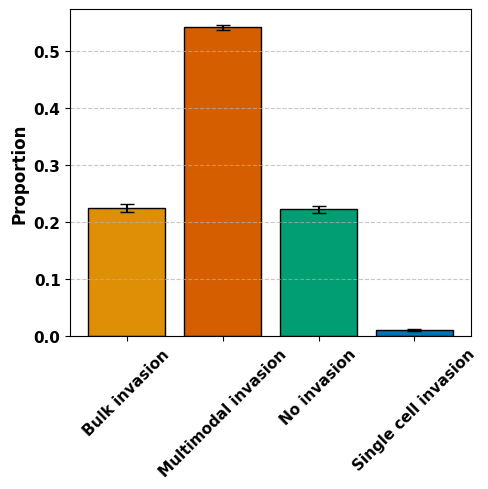

Bar chart with error bars saved to: ../../Results/Plots/Phenotypes/phenotype_distribution.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Load data
# =========================
file_path = "../../Results/Data/phenotype_classification.csv"
df = pd.read_csv(file_path)

# =========================
# Reconstruct replicate index
# =========================
# We treat each unique combination of parameters as one "situation"
# and each row with the same triple as a replicate of that situation.
df["Replicate"] = (
    df.groupby(["Contact Energy",
                "Chemotaxis Lambda",
                "Proliferative Probability"])
      .cumcount()
)


n_reps = df["Replicate"].nunique()
print(f"Number of replicate indices found: {n_reps}")
print(df["Replicate"].value_counts().sort_index().head())


df = df[df["Replicate"] <= 9]

# =========================
# Compute phenotype proportions per replicate
# =========================
# Count how many times each phenotype appears in each replicate
counts = (
    df.groupby(["Replicate", "Phenotype"])
      .size()
      .unstack(fill_value=0)   # rows: replicates, columns: phenotypes
)

# Convert counts to proportions per replicate
props = counts.div(counts.sum(axis=1), axis=0)

# Mean and standard deviation across replicates
phenotype_means = props.mean(axis=0)
phenotype_stds  = props.std(axis=0, ddof=1)   # use /sqrt(n) for SEM if desired

# Sort by phenotype name to have consistent order
phenotype_means = phenotype_means.sort_index()
phenotype_stds  = phenotype_stds.loc[phenotype_means.index]

print("Mean phenotype proportions across replicates:")
print(phenotype_means)

# =========================
# Colors (your mapping)
# =========================
cb_palette = sns.color_palette("colorblind")
bar_colors = {
    "No invasion": cb_palette[2],           # sky blue
    "Single cell invasion": cb_palette[0],  # blue
    "Bulk invasion": cb_palette[1],         # orange
    "Multimodal invasion": cb_palette[3]    # gold
}

phenotypes = phenotype_means.index.tolist()
color_list = [bar_colors[phen] for phen in phenotypes]

# =========================
# Plot with error bars
# =========================
plt.figure(figsize=(5, 5))

bars = plt.bar(
    phenotypes,
    phenotype_means.values,
    yerr=phenotype_stds.values,   
    capsize=5,
    color=color_list,
    edgecolor="black"
)

plt.ylabel("Proportion", fontsize=12, weight="bold")
plt.xticks(rotation=45, fontsize=11, weight="bold")
plt.yticks(fontsize=11, weight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.7)


# plt.ylim(0, 1)

plt.tight_layout()

# =========================
# Save and show
# =========================
save_path = "../../Results/Plots/Phenotypes/phenotype_distribution.png"
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Bar chart with error bars saved to: {save_path}")


### Phenotype Mix Across Parameter Values

/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_66926/1631516939.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phenos.groupby(["PP_bin", "Phenotype"], observed=True).size()


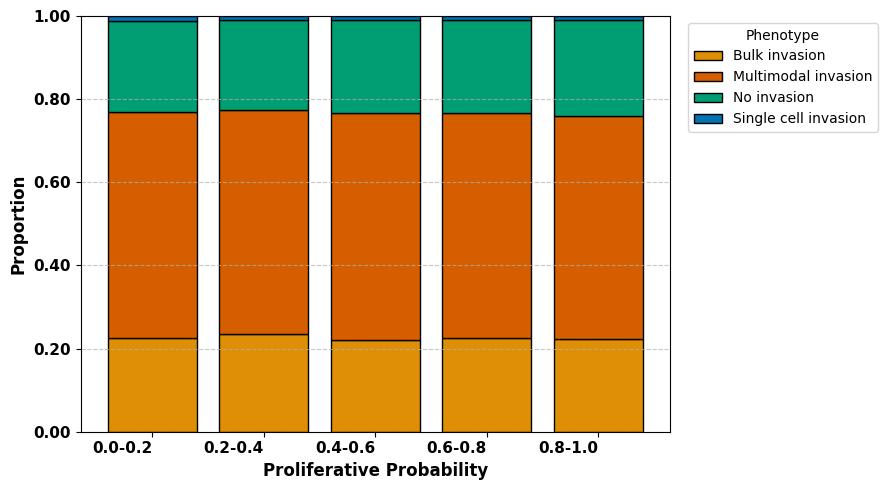

/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_66926/1631516939.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phenos.groupby(["PP_bin", "Phenotype"], observed=True).size()


Stacked phenotype-by-PP-bin chart saved to: ../../Results/Plots/Phenotypes/phenotype_distribution_by_PP.png


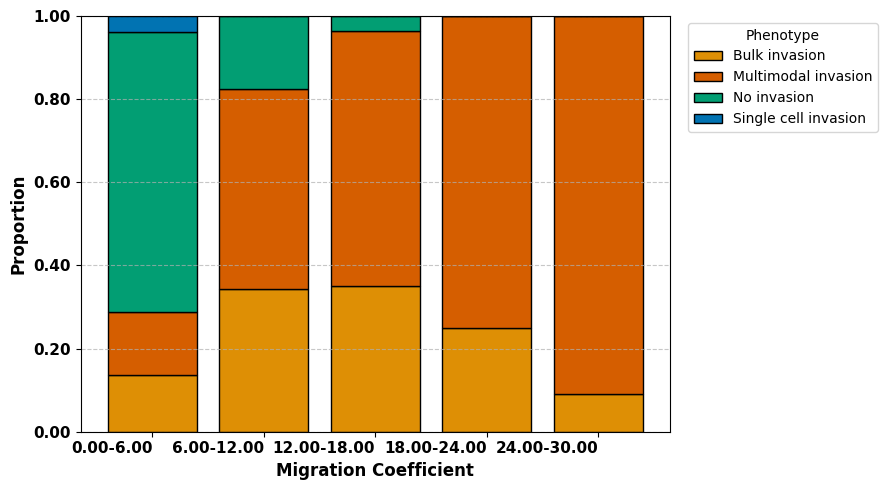

Stacked phenotype-by-bin chart saved to: ../../Results/Plots/Phenotypes/phenotype_distribution_by_migration_coefficient.png


/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_66926/1631516939.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phenos.groupby(["PP_bin", "Phenotype"], observed=True).size()


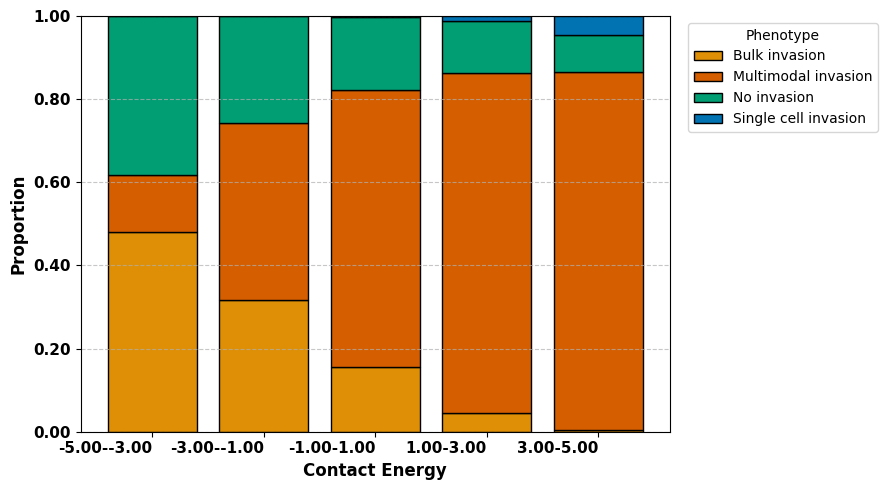

Stacked phenotype-by-bin chart saved to: ../../Results/Plots/Phenotypes/phenotype_distribution_by_contact_energy.png


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ================================
# Load data
# ================================
file_path = "../../Results/Data/phenotype_classification.csv"
df = pd.read_csv(file_path)

# ================================
# Colors & phenotype order (match your style)
# ================================
cb_palette = sns.color_palette("colorblind")
bar_colors = {
    "No invasion": cb_palette[2],           # sky blue
    "Single cell invasion": cb_palette[0],  # blue
    "Bulk invasion": cb_palette[1],         # orange
    "Multimodal invasion": cb_palette[3]    # gold
}
phenotype_order = ["Bulk invasion", "Multimodal invasion", "No invasion", "Single cell invasion"]

save_dir = "../../Results/Plots/Phenotypes"
os.makedirs(save_dir, exist_ok=True)

# =========================================================
# 1) Proliferative Probability  (bins fixed to 0..1)
# =========================================================
inv = df.copy()
if "Proliferative Probability" not in inv.columns:
    raise KeyError("Column 'Proliferative Probability' not found in the CSV.")
if "Phenotype" not in inv.columns:
    raise KeyError("Column 'Phenotype' not found in the CSV.")

bins = np.linspace(0, 1.0, 6)  # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins) - 1)]

# Cut and clean
inv["PP_bin"] = pd.cut(inv["Proliferative Probability"], bins=bins, labels=labels, include_lowest=True)
phenos = inv.dropna(subset=["Phenotype", "PP_bin"]).copy()

phenos["PP_bin"] = phenos["PP_bin"].astype("category")
phenos["Phenotype"] = phenos["Phenotype"].astype("category")

prop = (
    phenos.groupby(["PP_bin", "Phenotype"], observed=True).size()
          .groupby(level=0).apply(lambda s: s / s.sum())
          .unstack(fill_value=0)
)
prop = prop.reindex(columns=[p for p in phenotype_order if p in prop.columns], fill_value=0)

# Plot
plt.figure(figsize=(9, 5))
x = np.arange(len(prop))
bottom = np.zeros(len(prop), dtype=float)
for col in prop.columns:
    plt.bar(x, prop[col].values, bottom=bottom, color=bar_colors.get(col, "#999999"), edgecolor="black", label=col)
    bottom += prop[col].values

plt.ylabel("Proportion", fontsize=12, weight="bold")
plt.xlabel("Proliferative Probability", fontsize=12, weight="bold")
plt.xticks(x, labels, rotation=0, ha="right", fontsize=11, weight="bold")
yticks = np.linspace(0, 1, 6)
plt.yticks(yticks, [f"{v:.2f}" for v in yticks], fontsize=11, weight="bold")
plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Phenotype", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_path = os.path.join(save_dir, "phenotype_distribution_by_PP.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Stacked phenotype-by-PP-bin chart saved to: {save_path}")

# =========================================================
# 2) Chemotaxis Lambda  (label as "Migration Coefficient")
# =========================================================
inv = df.copy()
if "Chemotaxis Lambda" not in inv.columns:
    raise KeyError("Column 'Chemotaxis Lambda' not found in the CSV.")
if "Phenotype" not in inv.columns:
    raise KeyError("Column 'Phenotype' not found in the CSV.")

vmin = np.nanmin(inv["Chemotaxis Lambda"].to_numpy(dtype=float))
vmax = np.nanmax(inv["Chemotaxis Lambda"].to_numpy(dtype=float))
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
    vmin, vmax = 0.0, 1.0
bins = np.linspace(vmin, vmax, 6)
labels = [f"{bins[i]:.2f}-{bins[i+1]:.2f}" for i in range(len(bins) - 1)]

inv["PP_bin"] = pd.cut(inv["Chemotaxis Lambda"], bins=bins, labels=labels, include_lowest=True)
phenos = inv.dropna(subset=["Phenotype", "PP_bin"]).copy()

phenos["PP_bin"] = phenos["PP_bin"].astype("category")
phenos["Phenotype"] = phenos["Phenotype"].astype("category")

prop = (
    phenos.groupby(["PP_bin", "Phenotype"], observed=True).size()
          .groupby(level=0).apply(lambda s: s / s.sum())
          .unstack(fill_value=0)
)
prop = prop.reindex(columns=[p for p in phenotype_order if p in prop.columns], fill_value=0)

plt.figure(figsize=(9, 5))
x = np.arange(len(prop))
bottom = np.zeros(len(prop), dtype=float)
for col in prop.columns:
    plt.bar(x, prop[col].values, bottom=bottom, color=bar_colors.get(col, "#999999"), edgecolor="black", label=col)
    bottom += prop[col].values

plt.ylabel("Proportion", fontsize=12, weight="bold")
plt.xlabel("Migration Coefficient", fontsize=12, weight="bold")  # <- requested label
plt.xticks(x, labels, rotation=0, ha="right", fontsize=11, weight="bold")
yticks = np.linspace(0, 1, 6)
plt.yticks(yticks, [f"{v:.2f}" for v in yticks], fontsize=11, weight="bold")
plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Phenotype", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_path = os.path.join(save_dir, "phenotype_distribution_by_migration_coefficient.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Stacked phenotype-by-bin chart saved to: {save_path}")

# =========================================================
# 3) Contact Energy
# =========================================================
inv = df.copy()
if "Contact Energy" not in inv.columns:
    raise KeyError("Column 'Contact Energy' not found in the CSV.")
if "Phenotype" not in inv.columns:
    raise KeyError("Column 'Phenotype' not found in the CSV.")

vmin = np.nanmin(inv["Contact Energy"].to_numpy(dtype=float))
vmax = np.nanmax(inv["Contact Energy"].to_numpy(dtype=float))
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
    vmin, vmax = 0.0, 1.0
bins = np.linspace(vmin, vmax, 6)
labels = [f"{bins[i]:.2f}-{bins[i+1]:.2f}" for i in range(len(bins) - 1)]

inv["PP_bin"] = pd.cut(inv["Contact Energy"], bins=bins, labels=labels, include_lowest=True)
phenos = inv.dropna(subset=["Phenotype", "PP_bin"]).copy()

phenos["PP_bin"] = phenos["PP_bin"].astype("category")
phenos["Phenotype"] = phenos["Phenotype"].astype("category")

prop = (
    phenos.groupby(["PP_bin", "Phenotype"], observed=True).size()
          .groupby(level=0).apply(lambda s: s / s.sum())
          .unstack(fill_value=0)
)
prop = prop.reindex(columns=[p for p in phenotype_order if p in prop.columns], fill_value=0)

plt.figure(figsize=(9, 5))
x = np.arange(len(prop))
bottom = np.zeros(len(prop), dtype=float)
for col in prop.columns:
    plt.bar(x, prop[col].values, bottom=bottom, color=bar_colors.get(col, "#999999"), edgecolor="black", label=col)
    bottom += prop[col].values

plt.ylabel("Proportion", fontsize=12, weight="bold")
plt.xlabel("Contact Energy", fontsize=12, weight="bold")
plt.xticks(x, labels, rotation=0, ha="right", fontsize=11, weight="bold")
yticks = np.linspace(0, 1, 6)
plt.yticks(yticks, [f"{v:.2f}" for v in yticks], fontsize=11, weight="bold")
plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Phenotype", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_path = os.path.join(save_dir, "phenotype_distribution_by_contact_energy.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Stacked phenotype-by-bin chart saved to: {save_path}")


/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_58775/2857749010.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phenos.groupby(["bin", "Phenotype"], observed=True).size()
/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_58775/2857749010.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phenos.groupby(["bin", "Phenotype"], observed=True).size()
/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_58775/2857749010.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current b

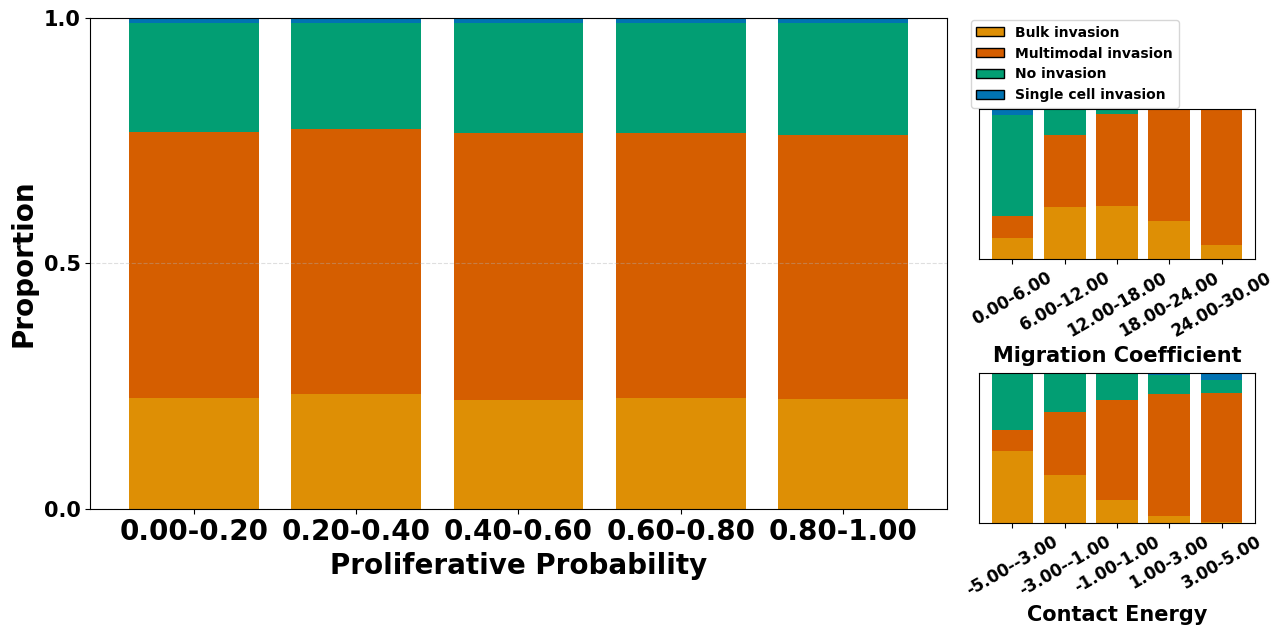

✅ Saved inset figure to: ../../Results/Plots/Phenotypes/phenotype_distribution_PP.png


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ================================
# Load data
# ================================
file_path = "../../Results/Data/phenotype_classification.csv"
df = pd.read_csv(file_path)
df.columns = [c.strip() for c in df.columns]

# ================================
# Colors & phenotype order
# ================================
cb_palette = sns.color_palette("colorblind")
bar_colors = {
    "No invasion": cb_palette[2],
    "Single cell invasion": cb_palette[0],
    "Bulk invasion": cb_palette[1],
    "Multimodal invasion": cb_palette[3],
}
phenotype_order = ["Bulk invasion", "Multimodal invasion", "No invasion", "Single cell invasion"]

save_dir = "../../Results/Plots/Phenotypes"
os.makedirs(save_dir, exist_ok=True)

# ================================
# Helper to compute stacked proportions
# ================================
def compute_prop(df, param_col, bins):
    labels = [f"{bins[i]:.2f}-{bins[i+1]:.2f}" for i in range(len(bins) - 1)]
    df = df.copy()
    df["bin"] = pd.cut(df[param_col], bins=bins, labels=labels, include_lowest=True)
    phenos = df.dropna(subset=["Phenotype", "bin"]).copy()
    phenos["bin"] = phenos["bin"].astype("category")
    phenos["Phenotype"] = phenos["Phenotype"].astype("category")
    prop = (
        phenos.groupby(["bin", "Phenotype"], observed=True).size()
              .groupby(level=0).apply(lambda s: s / s.sum())
              .unstack(fill_value=0)
    )
    prop = prop.reindex(columns=[p for p in phenotype_order if p in prop.columns], fill_value=0)
    return prop, labels

def plot_stacked(ax, prop, labels, xlabel, inset=False):
    x = np.arange(len(prop))
    bottom = np.zeros(len(prop))
    for col in prop.columns:
        ax.bar(
            x,
            prop[col].values,
            bottom=bottom,
            color=bar_colors.get(col, "#999999"),
            # edgecolor="black"   
        )
        bottom += prop[col].values
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30 if inset else 0, fontsize=12 if inset else 20, weight="bold")
    ax.set_ylim(0, 1.0)
    if inset:
        ax.set_yticks([])
        ax.set_ylabel("")
    else:
        ax.set_yticks([0, 0.5, 1.0])
        ax.set_yticklabels([f"{y:.1f}" for y in [0, 0.5, 1.0]], fontsize=15, weight="bold")
        ax.set_ylabel("Proportion", fontsize=20, weight="bold")
    ax.set_xlabel(xlabel, fontsize=15 if inset else 20, weight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

# ================================
# Main PP plot
# ================================
bins_pp = np.linspace(0, 1.0, 6)
prop_pp, labels_pp = compute_prop(df, "Proliferative Probability", bins_pp)

fig, ax = plt.subplots(figsize=(12, 6))
plot_stacked(ax, prop_pp, labels_pp, "Proliferative Probability", inset=False)

handles = [plt.Rectangle((0,0),1,1, color=bar_colors[p], ec="black") for p in phenotype_order]
legend = ax.legend(
    handles, phenotype_order,
    # title="Phenotype",
    bbox_to_anchor=(1.02, 1.01),
    loc="upper left",
    fontsize=12,
    title_fontsize=12,
    prop={"weight": "bold"}  
)
plt.setp(legend.get_title(), fontweight="bold") 

# ================================
# Inset 1: Migration Coefficient (Chemotaxis Lambda)
# ================================
bins_mc = np.linspace(df["Chemotaxis Lambda"].min(), df["Chemotaxis Lambda"].max(), 6)
prop_mc, labels_mc = compute_prop(df, "Chemotaxis Lambda", bins_mc)
ax_inset1 = fig.add_axes([0.82, 0.56, 0.23, 0.25])  
plot_stacked(ax_inset1, prop_mc, labels_mc, "Migration Coefficient", inset=True)

# ================================
# Inset 2: Contact Energy
# ================================
bins_ce = np.linspace(df["Contact Energy"].min(), df["Contact Energy"].max(), 6)
prop_ce, labels_ce = compute_prop(df, "Contact Energy", bins_ce)
ax_inset2 = fig.add_axes([0.82, 0.12, 0.23, 0.25])  
plot_stacked(ax_inset2, prop_ce, labels_ce, "Contact Energy", inset=True)

plt.tight_layout()
save_path = os.path.join(save_dir, "phenotype_distribution_PP.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Saved inset figure to: {save_path}")


/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_58775/2804595684.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phenos.groupby(["bin", "Phenotype"], observed=True).size()
/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_58775/2804595684.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phenos.groupby(["bin", "Phenotype"], observed=True).size()
/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_58775/2804595684.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current b

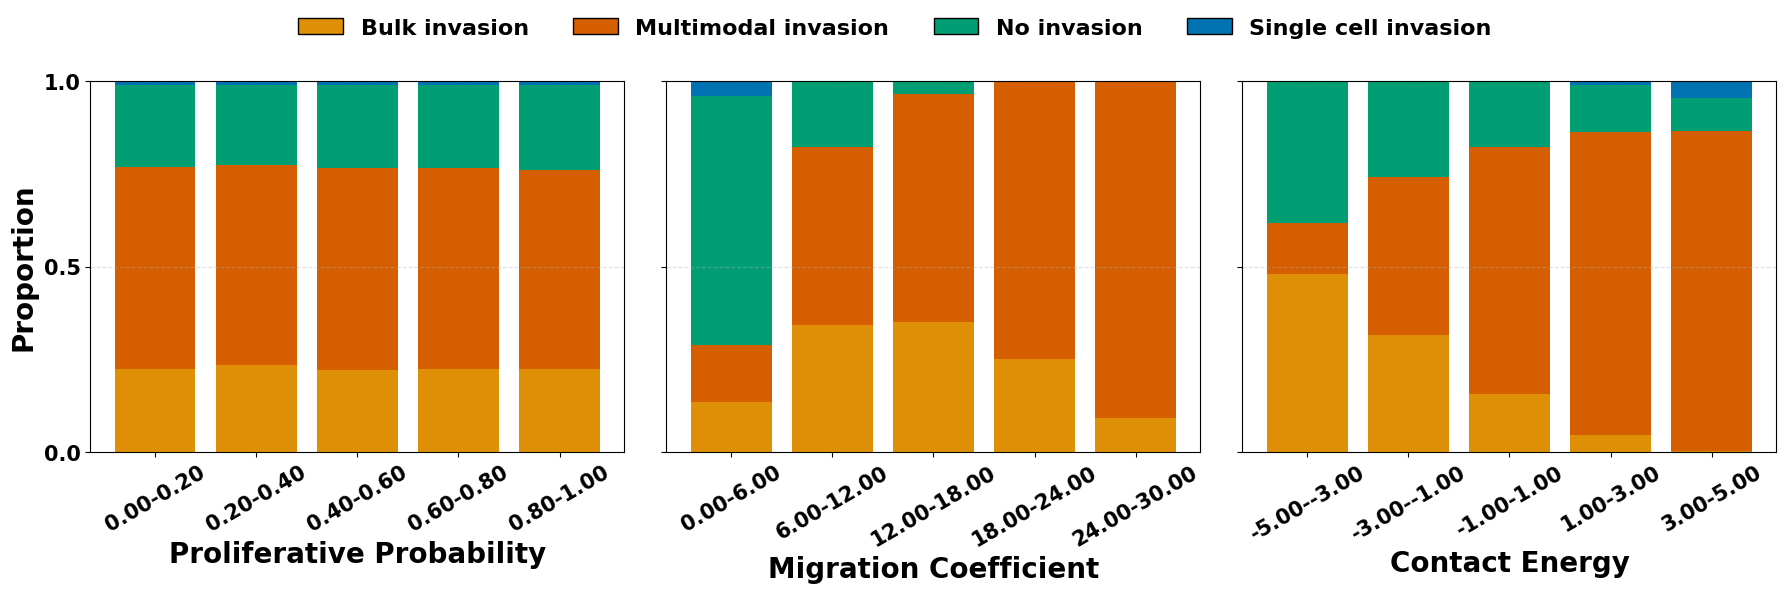

✅ Saved 3-panel side-by-side figure to: ../../Results/Plots/Phenotypes/phenotype_distribution_parameter.png


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ================================
# Load data
# ================================
file_path = "../../Results/Data/phenotype_classification.csv"
df = pd.read_csv(file_path)
df.columns = [c.strip() for c in df.columns]

# ================================
# Colors & phenotype order
# ================================
cb_palette = sns.color_palette("colorblind")
bar_colors = {
    "No invasion": cb_palette[2],
    "Single cell invasion": cb_palette[0],
    "Bulk invasion": cb_palette[1],
    "Multimodal invasion": cb_palette[3],
}
phenotype_order = ["Bulk invasion", "Multimodal invasion", "No invasion", "Single cell invasion"]

save_dir = "../../Results/Plots/Phenotypes"
os.makedirs(save_dir, exist_ok=True)

# ================================
# Helper to compute stacked proportions
# ================================
def compute_prop(df, param_col, bins):
    labels = [f"{bins[i]:.2f}-{bins[i+1]:.2f}" for i in range(len(bins) - 1)]
    df = df.copy()
    df["bin"] = pd.cut(df[param_col], bins=bins, labels=labels, include_lowest=True)

    phenos = df.dropna(subset=["Phenotype", "bin"]).copy()
    phenos["bin"] = phenos["bin"].astype("category")
    phenos["Phenotype"] = phenos["Phenotype"].astype("category")

    prop = (
        phenos.groupby(["bin", "Phenotype"], observed=True).size()
              .groupby(level=0).apply(lambda s: s / s.sum())
              .unstack(fill_value=0)
    )

    # Ensure consistent column order
    prop = prop.reindex(columns=[p for p in phenotype_order if p in prop.columns], fill_value=0)
    return prop, labels

# ================================
# Helper to plot stacked bar proportions
# ================================
def plot_stacked(ax, prop, labels, xlabel, inset=False):
    x = np.arange(len(prop))
    bottom = np.zeros(len(prop))

    for col in prop.columns:
        ax.bar(
            x,
            prop[col].values,
            bottom=bottom,
            color=bar_colors.get(col, "#999999"),
            # edgecolor="black"
        )
        bottom += prop[col].values

    ax.set_xticks(x)
    ax.set_xticklabels(
        labels,
        rotation=30,          # keep some rotation for readability
        fontsize=15,
        weight="bold"
    )
    ax.set_ylim(0, 1.0)

    if inset:
        ax.set_yticks([])
        ax.set_ylabel("")
    else:
        ax.set_yticks([0, 0.5, 1.0])
        ax.set_yticklabels(
            [f"{y:.1f}" for y in [0, 0.5, 1.0]],
            fontsize=15,
            weight="bold"
        )
        ax.set_ylabel("Proportion", fontsize=20, weight="bold")

    ax.set_xlabel(xlabel, fontsize=20, weight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

# ================================
# Compute proportions for all three parameters
# ================================
# 1) Proliferative Probability (PP)
bins_pp = np.linspace(0, 1.0, 6)
prop_pp, labels_pp = compute_prop(df, "Proliferative Probability", bins_pp)

# 2) Migration Coefficient (Chemotaxis Lambda)
bins_mc = np.linspace(df["Chemotaxis Lambda"].min(), df["Chemotaxis Lambda"].max(), 6)
prop_mc, labels_mc = compute_prop(df, "Chemotaxis Lambda", bins_mc)

# 3) Contact Energy (Adhesion)
bins_ce = np.linspace(df["Contact Energy"].min(), df["Contact Energy"].max(), 6)
prop_ce, labels_ce = compute_prop(df, "Contact Energy", bins_ce)

# ================================
# Main figure: 3 panels side-by-side
# ================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Panel 1: Proliferative Probability
plot_stacked(axes[0], prop_pp, labels_pp, "Proliferative Probability", inset=False)

# Panel 2: Migration Coefficient
plot_stacked(axes[1], prop_mc, labels_mc, "Migration Coefficient", inset=False)

# Panel 3: Contact Energy
plot_stacked(axes[2], prop_ce, labels_ce, "Contact Energy", inset=False)

# Only left panel needs y-label (shared y-axis)
axes[1].set_ylabel("")
axes[2].set_ylabel("")

# ================================
# Shared legend on top (bigger, bold)
# ================================
handles = [
    plt.Rectangle((0, 0), 1, 1, color=bar_colors[p], ec="black")
    for p in phenotype_order
]

fig.legend(
    handles,
    phenotype_order,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=4,
    prop={"size": 16, "weight": "bold"},
    frameon=False
)

# Make space for legend at the top
plt.tight_layout(rect=[0, 0, 1, 0.9])

save_path = os.path.join(save_dir, "phenotype_distribution_parameter.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Saved 3-panel side-by-side figure to: {save_path}")
